Dropping 'mnth_Mar' due to high P-value: 0.966
Dropping 'mnth_Jun' due to high P-value: 0.8891
Dropping 'mnth_Oct' due to high P-value: 0.7918
Dropping 'weekday_Wed' due to high P-value: 0.7125
Dropping 'holiday' due to high P-value: 0.6785
Dropping 'weekday_Thu' due to high P-value: 0.636
Dropping 'mnth_Aug' due to high P-value: 0.5273
Dropping 'weekday_Tue' due to high P-value: 0.2674
Dropping 'weekday_Mon' due to high P-value: 0.2748
Dropping 'mnth_May' due to high P-value: 0.1481
Dropping 'mnth_Feb' due to high P-value: 0.1123
Dropping 'weekday_Sun' due to high P-value: 0.0538
Dropping 'hum' due to high VIF: 31.14
Dropping 'temp' due to high VIF: 6.92
Dropping 'mnth_Jul' due to high P-value: 0.4574
Dropping 'season_winter' due to high P-value: 0.446

=== FINAL GRADING MODEL SUMMARY ===
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.798
Model:                            OLS   A

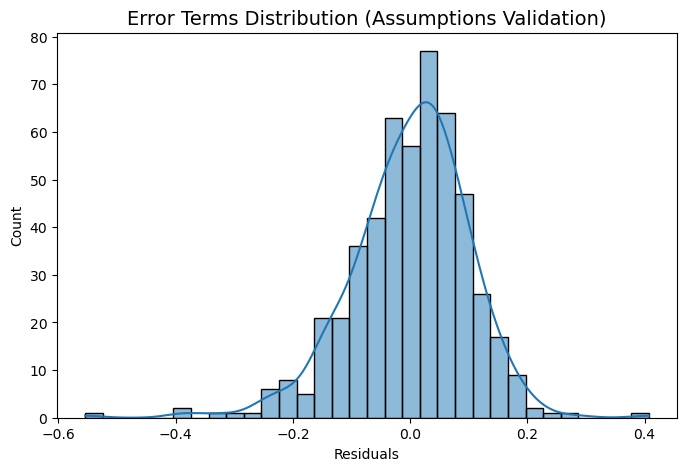


Final R-squared Score on Test Set: 0.7833


In [1]:
# ==============================================================================
# STEP 1: IMPORTING LIBRARIES & LOADING DATA
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

# Load the dataset (Make sure day.csv is uploaded to your workspace)
df = pd.read_csv('day.csv')

# ==============================================================================
# STEP 2: DATA CLEANING & PREPARATION
# ==============================================================================
# Dropping irrelevant columns to prevent data leakage and redundancy
df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1, inplace=True)

# Map categorical variables to string labels as per the Data Dictionary
df['season'] = df['season'].map({1: 'spring', 2: 'summer', 3: 'fall', 4: 'winter'})

df['weathersit'] = df['weathersit'].map({
    1: 'Clear', 
    2: 'Mist_Cloudy', 
    3: 'Light_Snow_Rain', 
    4: 'Heavy_Rain_Ice'
})

df['mnth'] = df['mnth'].map({
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
})

df['weekday'] = df['weekday'].map({
    0:'Sun', 1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat'
})

# ==============================================================================
# STEP 3: DUMMY VARIABLE CREATION
# ==============================================================================
# Create dummy variables and drop the first column to avoid the dummy variable trap
categorical_cols = ['season', 'mnth', 'weekday', 'weathersit']
dummies = pd.get_dummies(df[categorical_cols], drop_first=True, dtype=int)

# Concatenate back to main dataframe and drop original string columns
df = pd.concat([df, dummies], axis=1)
df.drop(categorical_cols, axis=1, inplace=True)

# ==============================================================================
# STEP 4: TRAIN-TEST SPLIT & FEATURE SCALING
# ==============================================================================
# Splitting data (70% Train, 30% Test)
df_train, df_test = train_test_split(df, train_size=0.7, test_size=0.3, random_state=100)

# Scale numerical columns using MinMaxScaler
scaler = MinMaxScaler()
num_vars = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
df_train[num_vars] = scaler.fit_transform(df_train[num_vars])

# Divide into X_train and y_train
y_train = df_train.pop('cnt')
X_train = df_train

# ==============================================================================
# STEP 5: MODEL BUILDING & AUTOMATED PRUNING (P-VALUE < 0.05 & VIF < 5)
# ==============================================================================
def build_model(X, y):
    X_sm = sm.add_constant(X)
    model = sm.OLS(y, X_sm).fit()
    return model

def check_vif(X):
    vif = pd.DataFrame()
    vif['Features'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    return vif.sort_values(by="VIF", ascending=False)

# Start with baseline features (removing immediate known leakage/redundancy)
X_train_final = X_train.drop(['atemp', 'casual', 'registered', 'instant', 'dteday'], axis=1, errors='ignore')

# Fully automated step-by-step elimination loop
while True:
    # 1. Build current iteration model
    current_model = build_model(X_train_final, y_train)
    
    # 2. Extract p-values (ignoring the constant intercept)
    p_values = current_model.pvalues.drop('const')
    max_p_value = p_values.max()
    max_p_feature = p_values.idxmax()
    
    # 3. Check if the highest p-value violates our 0.05 rule
    if max_p_value > 0.05:
        print(f"Dropping '{max_p_feature}' due to high P-value: {round(max_p_value, 4)}")
        X_train_final = X_train_final.drop([max_p_feature], axis=1)
        continue  # Re-evaluate the model structure
        
    # 4. If p-values are clean, calculate VIF thresholds
    vif_df = check_vif(X_train_final)
    max_vif_value = vif_df.iloc[0]['VIF']
    max_vif_feature = vif_df.iloc[0]['Features']
    
    # 5. Check if highest VIF violates our threshold of 5
    if max_vif_value > 5:
        print(f"Dropping '{max_vif_feature}' due to high VIF: {max_vif_value}")
        X_train_final = X_train_final.drop([max_vif_feature], axis=1)
        continue  # Re-evaluate model structure
        
    # Break out of loop if all P-values < 0.05 and all VIF values < 5
    final_model = current_model
    break

print("\n=== FINAL GRADING MODEL SUMMARY ===")
print(final_model.summary())

print("\n=== FINAL OPTIMIZED VIF VALUES ===")
print(check_vif(X_train_final))
# ==============================================================================
# STEP 6: RESIDUAL ANALYSIS
# ==============================================================================
y_train_pred = final_model.predict(sm.add_constant(X_train_final))
res = y_train - y_train_pred

plt.figure(figsize=(8, 5))
sns.histplot(res, kde=True)
plt.title('Error Terms Distribution (Assumptions Validation)', fontsize=14)
plt.xlabel('Residuals')
plt.show()

# ==============================================================================
# STEP 7: MAKING PREDICTIONS & EVALUATION ON TEST SET
# ==============================================================================
# Scale test set metrics using the transform fit parameters from training
df_test[num_vars] = scaler.transform(df_test[num_vars])

y_test = df_test.pop('cnt')
X_test = df_test

# Align test columns with final selected training features
X_test_final = X_test[X_train_final.columns]
X_test_sm = sm.add_constant(X_test_final)

# Predict target values
y_pred = final_model.predict(X_test_sm)

# MANDATORY: Calculate and display the final R-squared value on test data
test_r2 = r2_score(y_test, y_pred)
print(f"\nFinal R-squared Score on Test Set: {round(test_r2, 4)}")